Задача 1

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [3]:
x = np.array([2, 4, 6, 8, 10, 12])
y = np.array([1.08, 0.36, 0.21, 0.12, 0.09, 0.04])

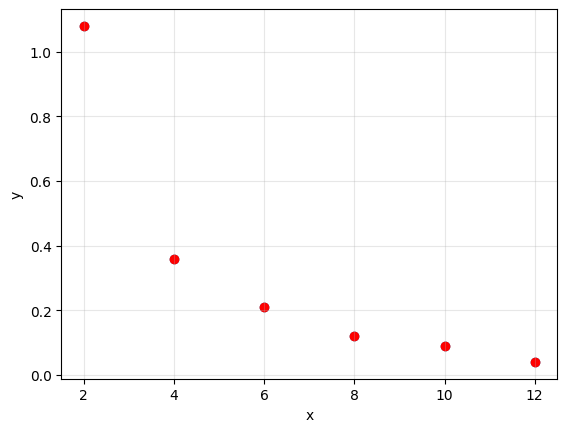

In [4]:
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.scatter(x, y, color='red')
plt.show()

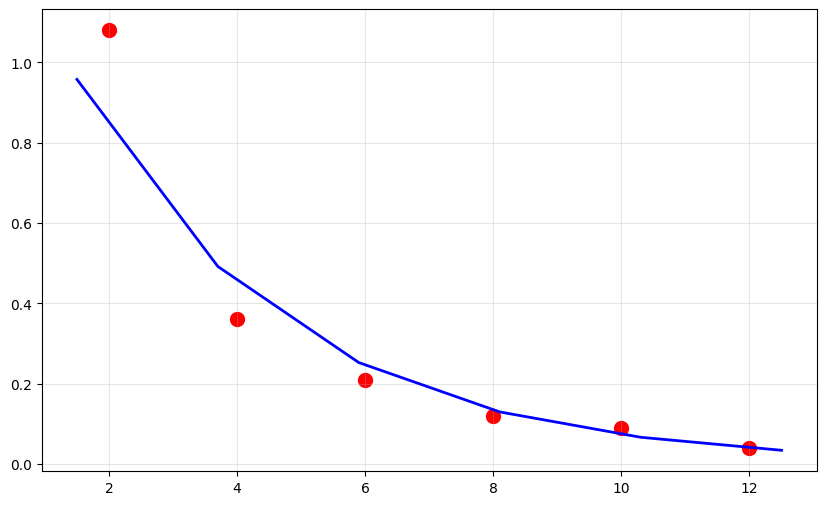

In [17]:
#аналитичекое
Y = np.log(y)

n = len(x)
sum_x = np.sum(x)
sum_Y = np.sum(Y)
sum_x2 = np.sum(x**2)
sum_xY = np.sum(x * Y)

# крамер
Delta = n * sum_x2 - sum_x**2
Delta_A = sum_Y * sum_x2 - sum_x * sum_xY
Delta_B = n * sum_xY - sum_x * sum_Y

A = Delta_A / Delta
B = Delta_B / Delta

a_analytic = np.exp(A)
b_analytic = B

x_fit = np.linspace(1.5, 12.5, 6)
y_fit_analytic = a_analytic * np.exp(b_analytic * x_fit)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='r', s=100)
plt.plot(x_fit, y_fit_analytic, 'b', linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

a = 1.508372
b = -0.302824

y = 1.508372 * e^(-0.302824·x)


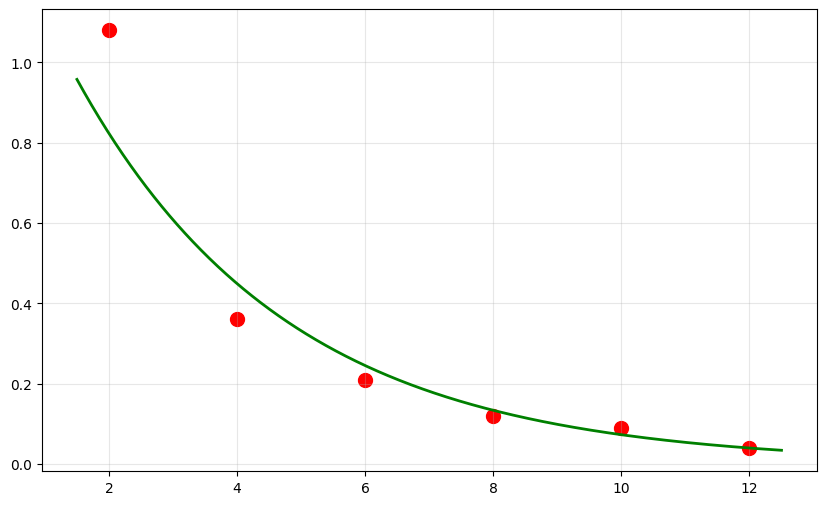

In [16]:
#numpy
coeffs = np.polyfit(x, Y, 1)
b_np = coeffs[0]
a_np = np.exp(coeffs[1])

print(f"a = {a_np:.6f}")
print(f"b = {b_np:.6f}")
print(f"\ny = {a_np:.6f} * e^({b_np:.6f}·x)")

# Построение графика
y_fit_np = a_np * np.exp(b_np * x_fit)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', s=100)
plt.plot(x_fit, y_fit_np, 'g', linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

a = 2.607865 +- 3.47e-01
b = -0.449402 +- 5.14e-02

y = 2.607865 * e^(-0.449402·x)


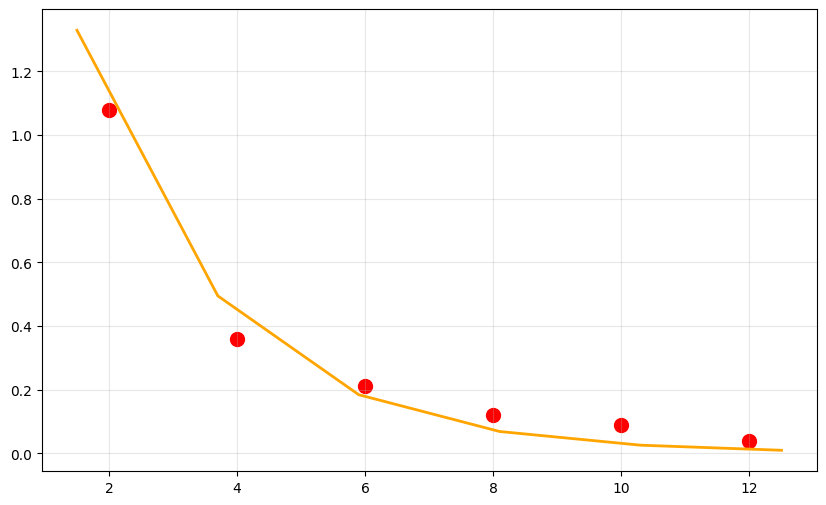

In [28]:
#scipy
def model(x, a, b):
    return a * np.exp(b * x)

# Подгонка параметров
popt, pcov = curve_fit(model, x, y, p0=[1, -0.2])
a_scipy, b_scipy = popt

perr = np.sqrt(np.diag(pcov))

print(f"a = {a_scipy:.6f} +- {perr[0]:.2e}")
print(f"b = {b_scipy:.6f} +- {perr[1]:.2e}")
print(f"\ny = {a_scipy:.6f} * e^({b_scipy:.6f}·x)")

y_fit_scipy = model(x_fit, a_scipy, b_scipy)
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', s=100)
plt.plot(x_fit, y_fit_scipy, 'orange', linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

   x       Аналитический          NumPy              SciPy       
  4.5         0.386093           0.386093           0.345150     
  5.0         0.331844           0.331844           0.275690     


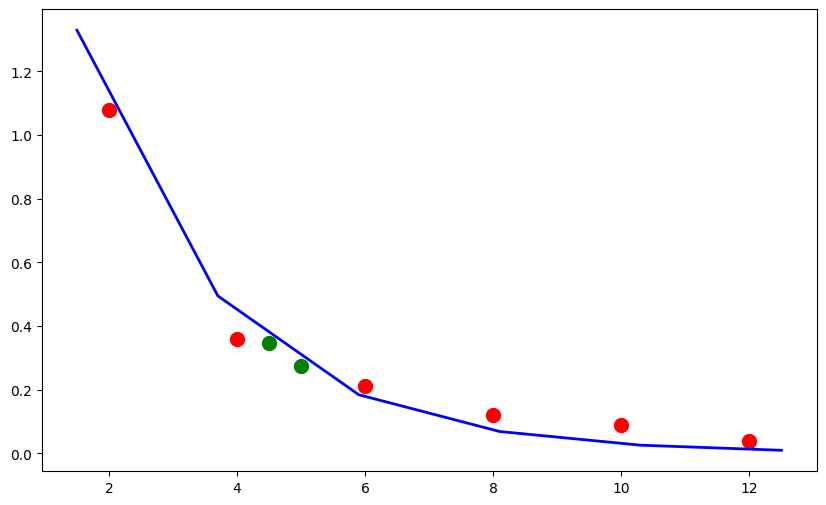

In [29]:
# прогноз
x_predict = np.array([4.5, 5.0])

#по каждому методу
y_pred_analytic_predict = a_analytic * np.exp(b_analytic * x_predict)
y_pred_np_predict = a_np * np.exp(b_np * x_predict)
y_pred_scipy_predict = a_scipy * np.exp(b_scipy * x_predict)

print(f"{'x':^8} {'Аналитический':^18} {'NumPy':^18} {'SciPy':^18}")
for i in range(len(x_predict)):
    print(f"{x_predict[i]:^8.1f} {y_pred_analytic_predict[i]:^18.6f} {y_pred_np_predict[i]:^18.6f} {y_pred_scipy_predict[i]:^18.6f}")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', s=100)
plt.plot(x_fit, y_fit_scipy, 'blue', linewidth=2)
plt.scatter(x_predict, y_pred_scipy_predict, color='green', s=100)
plt.show()
